In [29]:
pip install adjustText

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("/home/rt334/Downloads/mutation_comparison_summary.csv") 
df.tail()

,Mutation / Event,Avg CD8 (Present),Avg CD8 (Absent),Difference
6,Loss 3p,4.82,414.41,-409.59
7,Loss 10q,0.00,356.41,-356.41
8,loss_of_heterozygosity_HLA,0.00,288.71,-288.71
9,Mutation NF2,0.00,290.86,-290.86
10,Mutation TP53,0.00,486.57,-486.57


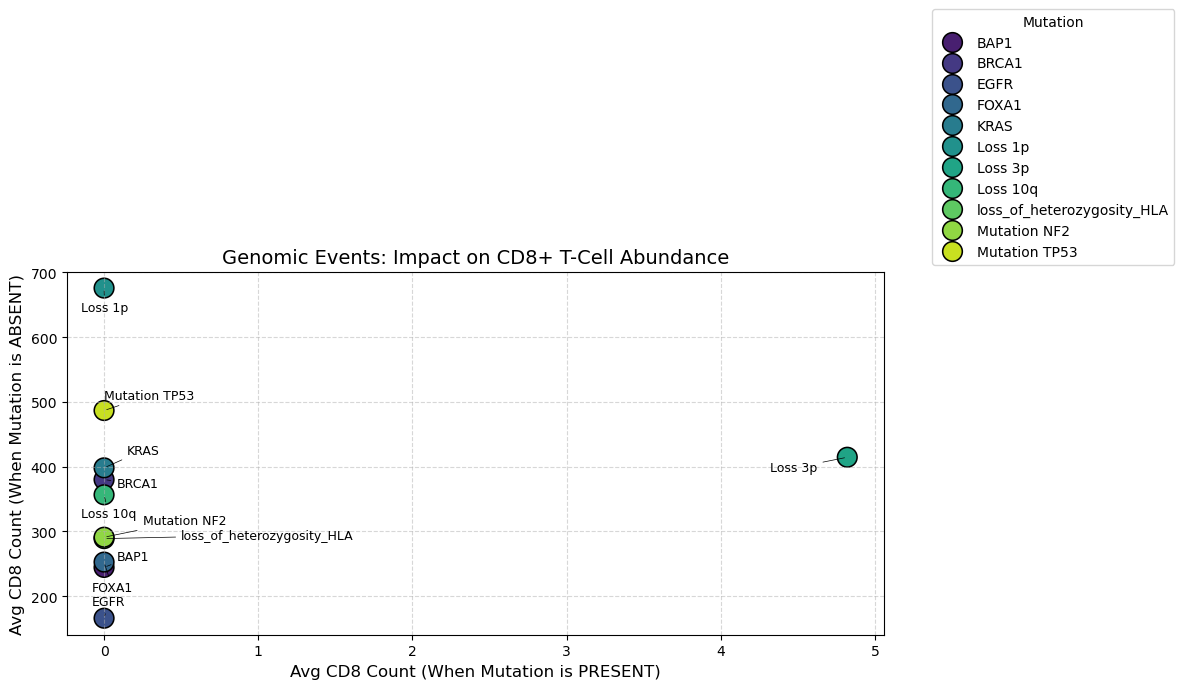

In [4]:
plot_df = df.copy()
# We map 'Present' to X and 'Absent' to Y so we can see the "drop"
plot_df["x"] = plot_df["Avg CD8 (Present)"].astype(float)
plot_df["y"] = plot_df["Avg CD8 (Absent)"].astype(float)

# Using the mutation name as the 'hue' so each point is identifiable
plot_df["mutation_name"] = plot_df["Mutation / Event"]

# Set figure size
plt.figure(figsize=(12, 7))

# The Scatterplot
sns.scatterplot(
    x="x",
    y="y",
    hue="mutation_name", 
    data=plot_df,
    palette="viridis",
    s=200,               # Larger points
    edgecolor='black'
)


#  Add annotations with manual offsets so every mutation label appears
offsets = [
    (0.08, 12),
    (0.08, -12),
    (-0.08, 20),
    (-0.08, -45),
    (0.15, 22),
    (-0.15, -35),
    (-0.5, -22),
    (-0.15, -35),
    (0.5, 0),
    (0.25, 20),
    (0, 18)
]

for i, row in plot_df.reset_index(drop=True).iterrows():
    dx, dy = offsets[i % len(offsets)]

    plt.annotate(
        row["Mutation / Event"],
        xy=(row["x"], row["y"]),
        xytext=(row["x"] + dx, row["y"] + dy),
        textcoords="data",
        fontsize=9,
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.5
        )
    )
# Creating the titles
plt.title("Genomic Events: Impact on CD8+ T-Cell Abundance", fontsize=14)
plt.xlabel("Avg CD8 Count (When Mutation is PRESENT)", fontsize=12)
plt.ylabel("Avg CD8 Count (When Mutation is ABSENT)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Move legend outside if it gets too crowded
plt.legend(bbox_to_anchor=(1.05, 1), loc='lower left', title="Mutation")

plt.tight_layout() 

plt.savefig(
    "Impact_on_CD8+_Tcell_Abundance.png",
    dpi=600, 
    facecolor="white"
)
plt.show()